Train R²: 0.9975
Test  R²: 0.9945
R² Gap (Train - Test): 0.0029
Train RMSE: 11.3184
Test  RMSE: 17.2362
RMSE Gap (Test - Train): 5.9178


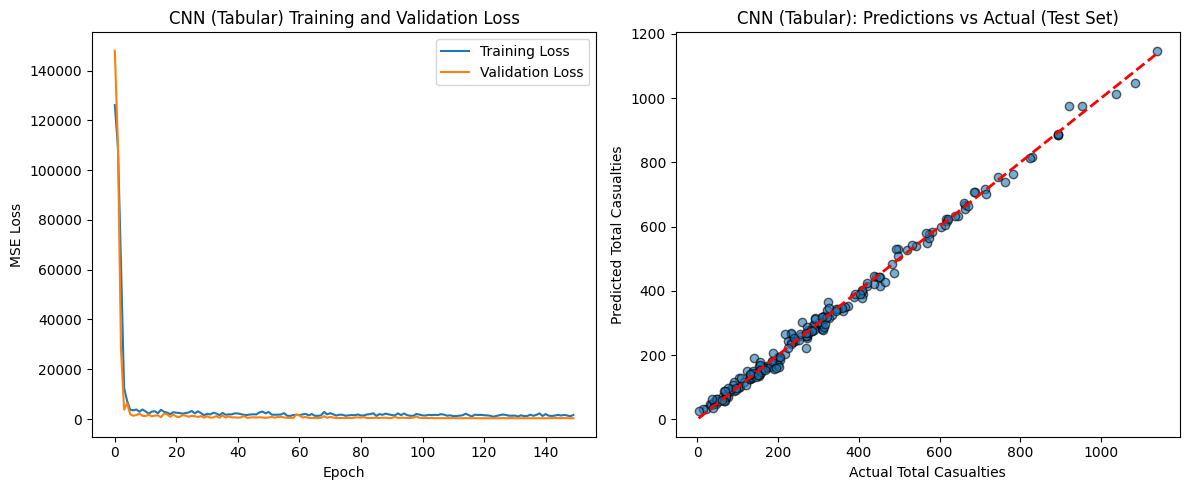

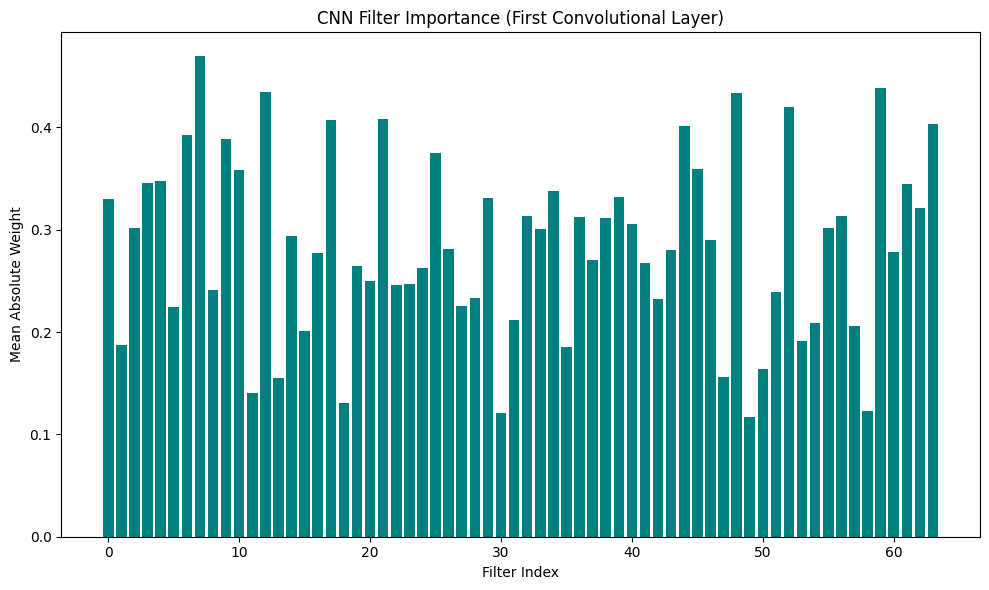

In [2]:
import subprocess
import sys
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch"])
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Augmented Dataset of Nigeria Crash.csv')
drop_cols = ['Quarter', 'State', 'Quarter_Date', 'State_Encoded']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
state_dummies = [c for c in df.columns if c.startswith('State_')]
df.drop(columns=state_dummies, inplace=True)
df = df.select_dtypes(include=[np.number])
df.dropna(inplace=True)
target = 'Total_Casualties'
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
n_features = X_train_scaled.shape[1]
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class CNN1DRegressor(nn.Module):
    def __init__(self, input_channels=1, n_features=100, conv_channels=[64, 128, 256], kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, conv_channels[0], kernel_size, padding=1)
        self.bn1 = nn.BatchNorm1d(conv_channels[0])
        self.conv2 = nn.Conv1d(conv_channels[0], conv_channels[1], kernel_size, padding=1)
        self.bn2 = nn.BatchNorm1d(conv_channels[1])
        self.conv3 = nn.Conv1d(conv_channels[1], conv_channels[2], kernel_size, padding=1)
        self.bn3 = nn.BatchNorm1d(conv_channels[2])
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(conv_channels[2], 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc_out = nn.Linear(64, 1)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.dropout(x)
        x = self.global_avg_pool(x).squeeze(-1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.fc_out(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN1DRegressor(input_channels=1, n_features=n_features, conv_channels=[64, 128, 256], kernel_size=3).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
num_epochs = 150
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    train_loss /= len(train_loader.dataset)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
    val_loss /= len(test_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_cnn_tabular.pth')
    else:
        patience_counter += 1
        if patience_counter >= 20:
            print(f'Early stopping at epoch {epoch+1}')
            break
model.load_state_dict(torch.load('best_cnn_tabular.pth'))
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor.to(device)).cpu().numpy().flatten()
    test_pred = model(X_test_tensor.to(device)).cpu().numpy().flatten()
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
gap_r2 = train_r2 - test_r2
gap_rmse = test_rmse - train_rmse
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"R² Gap (Train - Test): {gap_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"RMSE Gap (Test - Train): {gap_rmse:.4f}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('CNN (Tabular) Training and Validation Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted Total Casualties')
plt.title('CNN (Tabular): Predictions vs Actual (Test Set)')
plt.tight_layout()
plt.savefig('cnn_tabular_results.png', dpi=150)
plt.show()
model.eval()
weights = []
def hook_fn(module, input, output):
    weights.append(module.weight.data.cpu().numpy())
hook_handle = model.conv1.register_forward_hook(hook_fn)
with torch.no_grad():
    _ = model(X_train_tensor[:1].to(device))
hook_handle.remove()
if weights:
    conv_weights = weights[0]
    importance = np.abs(conv_weights).mean(axis=(1, 2))
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(importance)), importance, color='teal')
    plt.xlabel('Filter Index')
    plt.ylabel('Mean Absolute Weight')
    plt.title('CNN Filter Importance (First Convolutional Layer)')
    plt.tight_layout()
    plt.savefig('cnn_filter_importance.png', dpi=150)
    plt.show()